In [ ]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


# ** VERİ ARTTIRMA YOK**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
94765736/94765736 [==============================] - 0s 0us/step
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.625
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 

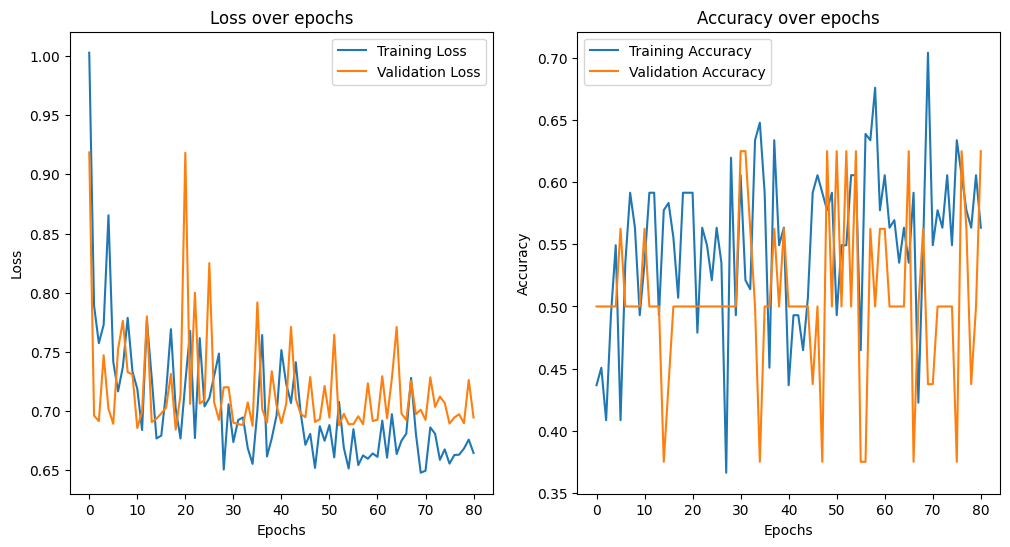

ValueError: Graph disconnected: cannot obtain value for tensor KerasTensor(type_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_270'), name='input_270', description="created by layer 'input_270'") at layer "stem_conv1". The following previous layers were accessed without issue: []

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,

    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,  # Shuffle the data
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,  # Do not shuffle the data
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200
early_stopping_patience = 50  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'ResNet50': ResNet50,
    'EfficientNetB0': EfficientNetB0,
    'VGG16': VGG16,
    'VGG19': VGG19,
    'InceptionV3': InceptionV3,
    'DenseNet121': DenseNet121,
    'DenseNet169': DenseNet169,
    'DenseNet201': DenseNet201,
    'MobileNetV2': MobileNetV2,
    'NASNetMobile': NASNetMobile
}

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = tf.keras.callbacks.EarlyStopping(
                        monitor='val_accuracy',
                        patience=early_stopping_patience,
                        restore_best_weights=True
                    )

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

best_model = Model(
    inputs=base_models[best_params['model']](weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3)).input,
    outputs=model.output
)
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history['loss'][-1])
print("Validation Loss:", history['val_loss'][-1])
print("Training Accuracy:", history['accuracy'][-1])
print("Validation Accuracy:", history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **VERi ARTTIRMA VAR**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
94765736/94765736 [==============================] - 0s 0us/step
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5625
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Drop

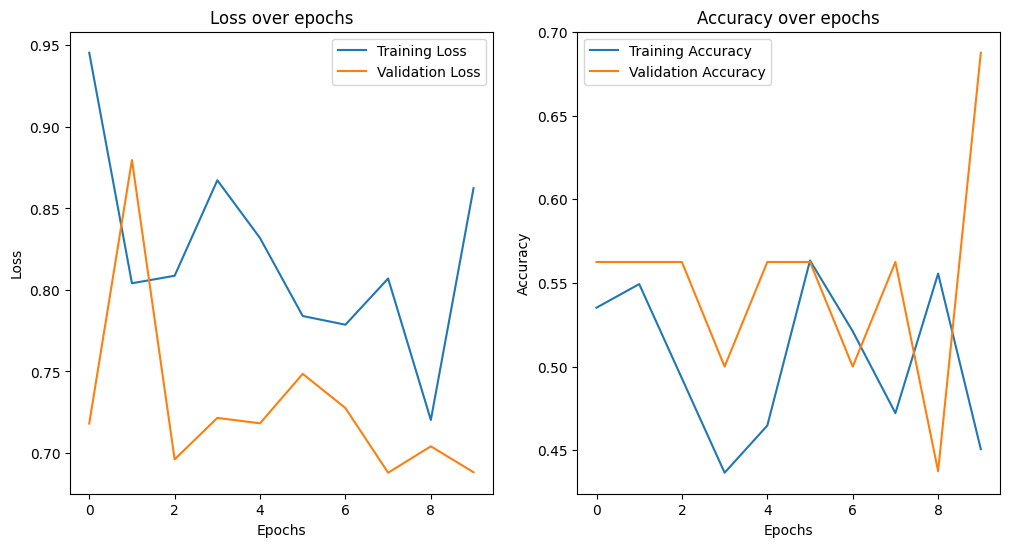

ValueError: Graph disconnected: cannot obtain value for tensor KerasTensor(type_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_270'), name='input_270', description="created by layer 'input_270'") at layer "stem_conv1". The following previous layers were accessed without issue: []

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'ResNet50': ResNet50,
    'EfficientNetB0': EfficientNetB0,
    'VGG16': VGG16,
    'VGG19': VGG19,
    'InceptionV3': InceptionV3,
    'DenseNet121': DenseNet121,
    'DenseNet169': DenseNet169,
    'DenseNet201': DenseNet201,
    'MobileNetV2': MobileNetV2,
    'NASNetMobile': NASNetMobile
}

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

best_model = Model(inputs=base_models[best_params['model']](weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3)).input, outputs=model.output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim

v1_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']   # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Modeli derleyelim
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    epochs=200,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples//val_generator.batch_size,
    #callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
58889256/58889256 [==============================] - 4s 0us/step
Epoch 1/200
18/18 [==============================] - 86s 4s/step - loss: 0.8135 - accuracy: 0.4507 - val_loss: 1.1935 - val_accuracy: 0.5000
Epoch 2/200
18/18 [==============================] - 5s 302ms/step - loss: 0.8089 - accuracy: 0.6479 - val_loss: 0.7084 - val_accuracy: 0.4375
Epoch 3/200
18/18 [==============================] - 5s 277ms/step - loss: 0.8006 - accuracy: 0.5493 - val_loss: 0.7678 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 5s 292ms/step - loss: 0.9286 - accuracy: 0.3944 - val_loss: 0.6765 - val_accuracy: 0.5625
Epoch 5/200
18/18 [==============================] - 5s 288ms/step - loss: 0.8638 - accuracy: 0.4648 - val_loss: 0.7503 - val_accuracy: 0.4375
Epoch 6/200
18/18 [==============================] - 5s 294ms/step - loss: 0.7905 - accuracy: 0.5775 - val_loss: 0.7786 - val_accuracy: 0.4375

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']   # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    epochs=200,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples//val_generator.batch_size,
    #callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
Epoch 1/200
18/18 [==============================] - 35s 352ms/step - loss: 0.7464 - accuracy: 0.3944 - val_loss: 0.6894 - val_accuracy: 0.5625
Epoch 2/200
18/18 [==============================] - 5s 277ms/step - loss: 0.7398 - accuracy: 0.4366 - val_loss: 0.6862 - val_accuracy: 0.5625
Epoch 3/200
18/18 [==============================] - 5s 292ms/step - loss: 0.6954 - accuracy: 0.5211 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 6s 306ms/step - loss: 0.7215 - accuracy: 0.5352 - val_loss: 0.6990 - val_accuracy: 0.4375
Epoch 5/200
18/18 [==============================] - 5s 294ms/step - loss: 0.6917 - accuracy: 0.6056 - val_loss: 0.6939 - val_accuracy: 0.5000
Epoch 6/200
18/18 [==============================] - 5s 288ms/step - loss: 0.6379 - accuracy: 0.5915 - val_loss: 0.6947 - val_accuracy: 0.5000
Epoch 7/200
18/18 [==============================] - 6s 325ms

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']   # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    epochs=100,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples//val_generator.batch_size,
    #callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
Epoch 1/100
18/18 [==============================] - 36s 368ms/step - loss: 0.7202 - accuracy: 0.4930 - val_loss: 0.7011 - val_accuracy: 0.5000
Epoch 2/100
18/18 [==============================] - 5s 292ms/step - loss: 0.6735 - accuracy: 0.5493 - val_loss: 0.6986 - val_accuracy: 0.4375
Epoch 3/100
18/18 [==============================] - 5s 291ms/step - loss: 0.6998 - accuracy: 0.5915 - val_loss: 0.6944 - val_accuracy: 0.4375
Epoch 4/100
18/18 [==============================] - 5s 285ms/step - loss: 0.6633 - accuracy: 0.5915 - val_loss: 0.6982 - val_accuracy: 0.4375
Epoch 5/100
18/18 [==============================] - 5s 298ms/step - loss: 0.6047 - accuracy: 0.6901 - val_loss: 0.6966 - val_accuracy: 0.5000
Epoch 6/100
18/18 [==============================] - 5s 285ms/step - loss: 0.6614 - accuracy: 0.6338 - val_loss: 0.7263 - val_accuracy: 0.4375
Epoch 7/100
18/18 [==============================] - 5s 302ms

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=200,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples // val_generator.batch_size,
    #callbacks=[early_stopping]
)
# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
80134624/80134624 [==============================] - 5s 0us/step
Epoch 1/200
18/18 [==============================] - 86s 4s/step - loss: 0.7401 - accuracy: 0.5493 - val_loss: 0.6865 - val_accuracy: 0.5625
Epoch 2/200
18/18 [==============================] - 6s 330ms/step - loss: 0.7973 - accuracy: 0.3944 - val_loss: 0.6947 - val_accuracy: 0.5000
Epoch 3/200
18/18 [==============================] - 5s 298ms/step - loss: 0.7526 - accuracy: 0.4507 - val_loss: 0.6821 - val_accuracy: 0.5625
Epoch 4/200
18/18 [==============================] - 6s 304ms/step - loss: 0.7032 - accuracy: 0.5915 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/200
18/18 [==============================] - 6s 308ms/step - loss: 0.8080 - accuracy: 0.4648 - val_loss: 0.6868 - val_accuracy: 0.5000
Epoch 6/200
18/18 [==============================] - 6s 319ms/step - loss: 0.7167 - accuracy: 0.5211 - val_loss: 0.6953 - val_accuracy: 0.5000

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=200,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples // val_generator.batch_size,
    #callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
train_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
val_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 1600
img_width = 1600
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout ekleyin
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Modeli derleyelim
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=50,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    #callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.


Epoch 1/50
18/18 [==============================] - 62s 3s/step - loss: 0.8601 - accuracy: 0.4225 - val_loss: 0.7007 - val_accuracy: 0.3750
Epoch 2/50
18/18 [==============================] - 56s 3s/step - loss: 0.7833 - accuracy: 0.4507 - val_loss: 0.7054 - val_accuracy: 0.4375
Epoch 3/50
18/18 [==============================] - 55s 3s/step - loss: 0.8557 - accuracy: 0.4366 - val_loss: 0.6844 - val_accuracy: 0.5625
Epoch 4/50
18/18 [==============================] - 56s 3s/step - loss: 0.7579 - accuracy: 0.5493 - val_loss: 0.6917 - val_accuracy: 0.5000
Epoch 5/50
18/18 [==============================] - 56s 3s/step - loss: 0.7996 - accuracy: 0.5070 - val_loss: 0.6807 - val_accuracy: 0.4375
Epoch 6/50
18/18 [==============================] - 55s 3s/step - loss: 0.7499 - accuracy: 0.5211 - val_loss: 0.6539 - val_accuracy: 0.5625
Epoch 7/50
18/18 [==============================] - 57s 3s/step - loss: 0.9720 - accuracy: 0.4306 - val_loss: 0.6844 - val_accuracy: 0.5000
Epoch 8/50
18/18 [==

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
train_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
val_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

# Grid'deki farklı hiperparametre kombinasyonlarını belirleyin
activations = ['relu', 'tanh', 'sigmoid']
num_layers = [1, 2, 3]
conv_layers = [1, 2]
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 50

best_accuracy = 0
best_params = {}

# Hiperparametre kombinasyonlarını deneyin
for activation in activations:
    for nl in num_layers:
        for cl in conv_layers:
            for dropout_rate in dropout_rates:
                for learning_rate in learning_rates:
                    # Modeli oluşturun
                    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)  # Aktivasyonu hiperparametre olarak ayarlayın
                    x = Dropout(dropout_rate)(x)  # Dropout'u hiperparametre olarak ayarlayın
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)

                    # Modeli derleyin
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Modeli eğitin
                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    # Modelin doğruluğunu değerlendirin
                    val_accuracy = history.history['val_accuracy'][-1]

                    # En iyi doğruluğu ve parametreleri güncelleyin
                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = {'activation': activation, 'num_layers': nl, 'conv_layers': cl, 'dropout_rate': dropout_rate, 'learning_rate': learning_rate}

# En iyi parametreleri ve performansı görüntüleyin
print("En iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

# Metrikleri yazdır
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
En iyi parametreler: {'activation': 'sigmoid', 'num_layers': 1, 'conv_layers': 1, 'dropout_rate': 0.1, 'learning_rate': 0.001}
En iyi skor: 0.625
5/5 [==============================] - 2s 346ms/step
Weighted Precision: 0.28027681660899656
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.36651583710407243
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.2647058823529412
Macro Recall: 0.5
Macro F1 Score: 0.3461538461538462
Precision (None): [0.         0.52941176]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.69230769]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
